# Does building hotel rooms pay off?

Hackathon 5, SDG 8.9 (sustainable tourism that creates jobs and growth).

Our question: if a country added a lot of hotel rooms in the last 3 years, does its tourism revenue grow faster than the rest of the world in the next 2 years?

We use hotel rooms as a stand-in for tourism investment, because there is no free dataset with investment money for all countries. Each row is one country in one year. The brief asks for one row per person or company, but this is a decision a country makes, so the country is the unit. We discussed the idea with our teacher.

The model can only show that the two things go together. It can't prove that building rooms causes more revenue, because hotels are often built where tourists are already coming.

## 1. The problem

- **Target:** `target_beats_world`. It's 1 if the country's tourism revenue grew more from year t to t+2 than the world median for the same years.
- **User:** a national tourism ministry, for example Morocco's Ministry of Tourism, deciding whether to back more hotel building (permits, tax breaks, public loans) for the next few years.
- **Who is affected:** hotel and restaurant workers, small tourism businesses, and the people who pay back the loans.
- **Worse mistake:** a false positive. The model says yes, money goes in, revenue doesn't follow, and you end up with empty hotels and debt. A false negative also costs something, because a country that would have done well gets no support.
- **Main metric:** F1, chosen before training. We care about both precision (when we say yes, are we right?) and recall (do we find the countries that would do well?). We also show precision on its own because false positives are a bit worse.

Why compare with the world instead of just asking "does it grow"? Crises and exchange-rate swings hit all countries at once. Comparing with the world median removes those shared shocks.

In [1]:
import json, warnings, zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
import sklearn
from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.exceptions import UndefinedMetricWarning
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay, confusion_matrix, f1_score,
                             precision_score, recall_score)
from sklearn.model_selection import GridSearchCV, StratifiedGroupKFold, cross_validate
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler

# the dummy baseline never predicts 1 in some folds, so precision is 0 there; that's expected
warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

SEED = 42
HORIZON = 2        # years ahead for the target
ROOMS_WINDOW = 3   # years back for room growth
COVID_YEARS = [2020, 2021, 2022]
DATA = Path("data/raw")
DATA.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
pd.set_option("display.max_columns", 40)
print("pandas", pd.__version__, "| scikit-learn", sklearn.__version__, "| numpy", np.__version__)

pandas 2.3.3 | scikit-learn 1.7.2 | numpy 2.3.5


## 2. Data

| Source | What we take from it | Licence |
|---|---|---|
| [UN Tourism bulk download (05/2026)](https://www.untourism.int/tourism-statistics/tourism-statistics-database). Collected every year from national statistics offices | hotel rooms, money spent by foreign visitors (US$ million), tourist arrivals | UN Tourism copyright, free for students. Not stored in our repo, the notebook downloads it |
| [World Bank WDI](https://data.worldbank.org) | exchange rate, GDP, GDP per person, inflation, region, income group | CC BY 4.0 |
| [datasets/country-codes](https://github.com/datasets/country-codes) | table to match UN country numbers to ISO codes | public domain |

Everything downloads once and is saved in `data/raw/`.

In [2]:
def cached(url, name, **params):
    path = DATA / name
    if not path.exists():
        response = requests.get(url, params=params, timeout=180)
        response.raise_for_status()
        path.write_bytes(response.content)
    return path

UN_ZIP = cached("https://pre-webunwto.s3.amazonaws.com/s3fs-public/2026-05/"
                "UN_Tourism_bulk_data_download_05_2026.zip", "UN_Tourism_bulk_05_2026.zip")
CODES = cached("https://raw.githubusercontent.com/datasets/country-codes/main/data/country-codes.csv",
               "country_codes.csv")
WB = {code: cached(f"https://api.worldbank.org/v2/country/all/indicator/{code}", f"wb_{code}.json",
                   format="json", per_page=20000, date="1990:2024")
      for code in ["PA.NUS.FCRF", "NY.GDP.MKTP.CD", "NY.GDP.PCAP.CD", "FP.CPI.TOTL.ZG"]}
WB_META = cached("https://api.worldbank.org/v2/country", "wb_countries.json", format="json", per_page=400)
for path in [UN_ZIP, CODES, *WB.values(), WB_META]:
    print(f"{path.name:40s} {path.stat().st_size/1e6:6.2f} MB")

UN_Tourism_bulk_05_2026.zip                8.91 MB
country_codes.csv                          0.13 MB
wb_PA.NUS.FCRF.json                        2.23 MB
wb_NY.GDP.MKTP.CD.json                     1.97 MB
wb_NY.GDP.PCAP.CD.json                     2.08 MB
wb_FP.CPI.TOTL.ZG.json                     2.15 MB
wb_countries.json                          0.11 MB


The UN files have one row per country, year and indicator. We keep three indicators plus the quality flags. Some values are marked as a "time series break", which means the country changed how it counts. Growth across a break isn't real growth, so we remove those rows later.

In [3]:
UN_FILES = {
    "rooms": ("Bulk/04_Accommodation/01_Accommodation_in_hotels_and_similar_establishments/"
              "UN_Tourism_accommodation_hotels_12_2025.xlsx", None),
    "spend_musd": ("Bulk/02_Inbound/02_Expenditure/UN_Tourism_inbound_expenditure_12_2025.xlsx",
                   "INBD_EXPD_BPAY_TRVL_VSTR"),
    "arrivals_k": ("Bulk/02_Inbound/01_Total_arrivals/UN_Tourism_inbound_arrivals_12_2025.xlsx",
                   "INBD_TRIP_TOTL_TOTL_TOUR"),
}
frames = []
with zipfile.ZipFile(UN_ZIP) as z:
    for name, (path, code) in UN_FILES.items():
        d = pd.read_excel(z.open(path), sheet_name="Data")
        d = d[d.indicator_label.str.endswith("- rooms")] if code is None else d[d.indicator_code == code]
        frames.append(d.assign(variable=name))
un_long = pd.concat(frames)
print("UN Tourism rows:", len(un_long))
display(un_long.groupby("variable").agg(countries=("reporter_area_code", "nunique"),
                                        values=("value", "count"), first_year=("year", "min"),
                                        last_year=("year", "max")))
display(un_long.groupby(["variable", "flag_label"]).size().rename("flagged values").to_frame())

UN Tourism rows: 15168


,countries,values,first_year,last_year
variable,,,,
arrivals_k,209,5241,1995,2024
rooms,203,4559,1995,2024
spend_musd,202,5368,1995,2024


flagged values
variable   flag_label                       
arrivals_k Estimated value                 8
           Time series break               1
rooms      Estimated value                 7
           Time series break               5

Next we join the two sources. UN Tourism uses UN number codes and the World Bank uses ISO letter codes, so the lookup table connects them. Regions like "World" have no ISO code and drop out. Values marked "low reliability" become missing.

In [4]:
codes = pd.read_csv(CODES, usecols=["M49", "ISO3166-1-Alpha-3"]).dropna()
m49_to_iso3 = dict(zip(codes.M49.astype(int), codes["ISO3166-1-Alpha-3"]))
un_long["iso3"] = un_long.reporter_area_code.map(m49_to_iso3)
print("Dropped, no ISO code:", sorted(un_long.loc[un_long.iso3.isna(), "reporter_area_label"].unique()))
un_long = un_long.dropna(subset=["iso3"])
low_reliability = un_long.flag_label.fillna("").str.contains("Low reliability")
print("Set to missing (low reliability):", int(low_reliability.sum()))
un_long.loc[low_reliability, "value"] = np.nan
un_long["is_break"] = un_long.flag_label.fillna("").str.contains("Time series break")
names = un_long.groupby("iso3").reporter_area_label.first()
un = un_long.pivot_table(index=["iso3", "year"], columns="variable", values="value", aggfunc="first")
breaks = un_long.pivot_table(index=["iso3", "year"], columns="variable", values="is_break",
                             aggfunc="max").add_suffix("_break")
un = un.join(breaks).reset_index()

meta = json.loads(WB_META.read_text())[1]
meta = pd.DataFrame([{"iso3": c["id"], "region": c["region"]["value"],
                      "income_group": c["incomeLevel"]["value"]}
                     for c in meta if c["region"]["value"] != "Aggregates"])
wb_names = {"PA.NUS.FCRF": "fx_lcu_per_usd", "NY.GDP.MKTP.CD": "gdp_usd",
            "NY.GDP.PCAP.CD": "gdp_per_capita_usd", "FP.CPI.TOTL.ZG": "inflation_pct"}
wb = pd.concat([pd.DataFrame([{"iso3": r["countryiso3code"], "year": int(r["date"]), wb_names[code]: r["value"]}
                              for r in json.loads(path.read_text())[1]
                              if r["value"] is not None and r["countryiso3code"]]).set_index(["iso3", "year"])
                for code, path in WB.items()], axis=1).reset_index()

panel = (un.merge(wb, on=["iso3", "year"], how="outer").merge(meta, on="iso3", how="inner")
           .sort_values(["iso3", "year"]).reset_index(drop=True))
panel["country"] = panel.iso3.map(names).fillna(panel.iso3)
print("Joined:", panel.shape, "|", panel.iso3.nunique(), "countries")

Dropped, no ISO code: ['Bonaire', 'Saba', 'St. Eustatius']
Set to missing (low reliability): 0
Joined: (7485, 15) | 216 countries


### Features and target

Features only use what is known at the end of year t. The target uses t+1 and t+2. If a year is missing, the value stays missing. We never fill it with a nearby year.

These are simple calculations per row, nothing is learned from the data, so doing them before the split doesn't leak anything. The world median is part of the label definition, not a feature.

| Feature | Meaning |
|---|---|
| `rooms_growth_3y` | change in hotel rooms over the last 3 years (the main feature) |
| `arrivals_growth_1y` | change in tourist arrivals over the last year |
| `spend_growth_past_1y` | change in tourism revenue over the last year |
| `spend_per_room_usd` | revenue divided by rooms, so how well rooms are used |
| `spend_share_gdp_pct` | tourism revenue as % of GDP |
| `fx_change_1y` | change in local currency per US$ (above 0 means the country got cheaper for visitors) |
| `gdp_per_capita_usd`, `inflation_pct` | how rich the country is and how stable prices are |
| `income_group`, `region` | World Bank groups, also used for the group check |

In [5]:
def at_offset(column, years):
    """Value of `column` for the same country exactly `years` later (negative = earlier)."""
    lookup = panel[["iso3", "year", column]].copy()
    lookup["year"] -= years
    return panel[["iso3", "year"]].merge(lookup, on=["iso3", "year"], how="left")[column].to_numpy()

panel["rooms_growth_3y"] = panel.rooms / at_offset("rooms", -ROOMS_WINDOW) - 1
panel["arrivals_growth_1y"] = panel.arrivals_k / at_offset("arrivals_k", -1) - 1
panel["spend_growth_past_1y"] = panel.spend_musd / at_offset("spend_musd", -1) - 1
panel["spend_per_room_usd"] = panel.spend_musd * 1e6 / panel.rooms
panel["spend_share_gdp_pct"] = panel.spend_musd * 1e6 / panel.gdp_usd * 100
panel["fx_change_1y"] = panel.fx_lcu_per_usd / at_offset("fx_lcu_per_usd", -1) - 1
panel = panel.replace([np.inf, -np.inf], np.nan)

panel["spend_growth_next_2y"] = at_offset("spend_musd", HORIZON) / panel.spend_musd - 1
panel["world_median_next_2y"] = panel.groupby("year").spend_growth_next_2y.transform("median")
panel["target_beats_world"] = (panel.spend_growth_next_2y > panel.world_median_next_2y).astype(float)
panel.loc[panel.spend_growth_next_2y.isna(), "target_beats_world"] = np.nan

To make it concrete, here is Morocco. The left chart shows the inputs (rooms) next to the outcome (revenue). The right chart shows how each year gets its label: revenue growth over the next 2 years against the world median.

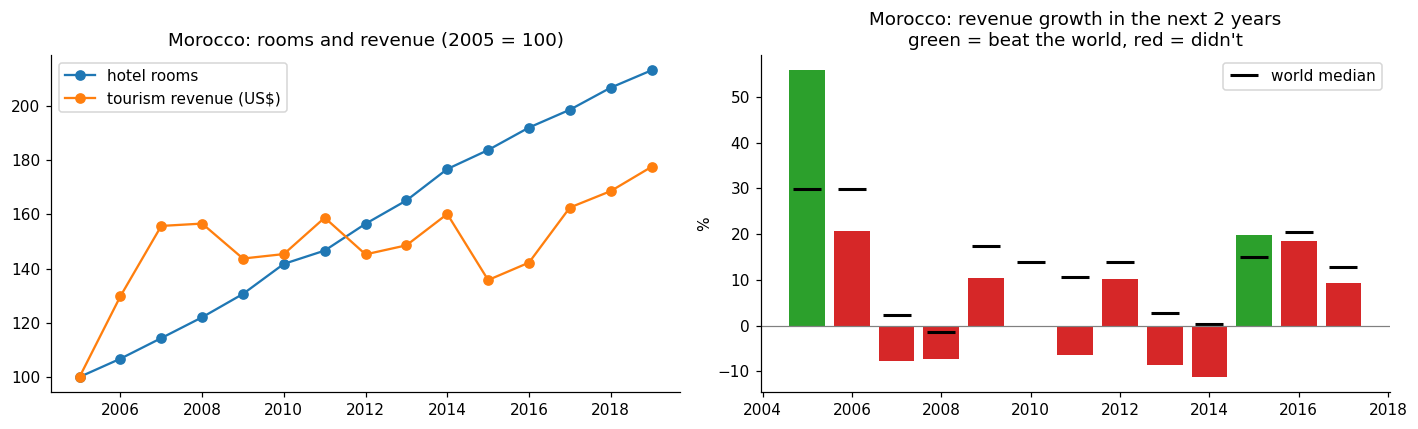

In [6]:
mar = panel.query("iso3 == 'MAR' and 2005 <= year <= 2019").set_index("year")
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
base = mar.loc[2005]
axes[0].plot(mar.index, mar.rooms / base.rooms * 100, marker="o", label="hotel rooms")
axes[0].plot(mar.index, mar.spend_musd / base.spend_musd * 100, marker="o", label="tourism revenue (US$)")
axes[0].set_title("Morocco: rooms and revenue (2005 = 100)")
axes[0].legend()

lab = mar.loc[2005:2017]
colors = np.where(lab.target_beats_world == 1, "tab:green", "tab:red")
axes[1].bar(lab.index, lab.spend_growth_next_2y * 100, color=colors)
axes[1].plot(lab.index, lab.world_median_next_2y * 100, "k_", markersize=18, mew=2, label="world median")
axes[1].axhline(0, color="grey", lw=0.8)
axes[1].set_title("Morocco: revenue growth in the next 2 years\ngreen = beat the world, red = didn't")
axes[1].set_ylabel("%")
axes[1].legend()
plt.tight_layout()
plt.show()

### Which rows we keep

A row stays only if:
1. the target is known (revenue for t and t+2)
2. rooms are known for t and t−3
3. no COVID year (2020 to 2022) falls between t−3 and t+2. That's why the last year is 2017
4. there's no time series break in rooms or revenue inside that window
5. room growth is between −50% and +200% over 3 years. Anything bigger is almost always a change in how rooms are counted. We set this rule before modelling.

In [7]:
def any_break(column, offsets):
    flags = np.zeros(len(panel), dtype=bool)
    for k in offsets:
        flags |= np.nan_to_num(at_offset(column, k).astype(float)).astype(bool)
    return flags

reasons = pd.DataFrame(index=panel.index)
reasons["no target (revenue t or t+2 missing)"] = panel.target_beats_world.isna()
reasons["no room growth (rooms t or t-3 missing)"] = panel.rooms_growth_3y.isna()
reasons["window touches COVID 2020-2022"] = panel.year.apply(
    lambda t: any(t - ROOMS_WINDOW <= y <= t + HORIZON for y in COVID_YEARS))
reasons["time series break in window"] = (any_break("rooms_break", [0, -1, -2])
                                          | any_break("spend_musd_break", [1, 2]))
reasons["room growth outside -50% to +200%"] = ~panel.rooms_growth_3y.between(-0.5, 2.0) & panel.rooms_growth_3y.notna()
first_reason = reasons.idxmax(axis=1).where(reasons.any(axis=1), "kept")
display(first_reason.value_counts().rename("rows (first reason)").to_frame())

df = panel[first_reason == "kept"].copy().reset_index(drop=True)
df["target_beats_world"] = df.target_beats_world.astype(int)
print(f"Modelling table: {len(df)} rows, {df.iso3.nunique()} countries, {df.year.min()}-{df.year.max()}")

,rows (first reason)
no target (revenue t or t+2 missing),2643
kept,2577
no room growth (rooms t or t-3 missing),1677
window touches COVID 2020-2022,570
room growth outside -50% to +200%,18


Modelling table: 2577 rows, 168 countries, 1998-2017


### Quick checks

Size, types, missing values, duplicates and class balance. We look at distributions after the split, on training data only.

Leakage: `spend_growth_next_2y`, `world_median_next_2y` and revenue at t+2 are only known after the outcome, so they're never features. We also leave out raw size columns (rooms, revenue, GDP), so the model can't just learn "big country".

In [8]:
NUMERIC = ["rooms_growth_3y", "arrivals_growth_1y", "spend_growth_past_1y", "fx_change_1y", "inflation_pct",
           "spend_per_room_usd", "spend_share_gdp_pct", "gdp_per_capita_usd"]
CATEGORICAL = ["income_group", "region"]
FEATURES = NUMERIC + CATEGORICAL
TARGET = "target_beats_world"
LABELS = {"rooms_growth_3y": "room growth (3 yr)", "arrivals_growth_1y": "arrivals growth (1 yr)",
          "spend_growth_past_1y": "revenue growth last year", "fx_change_1y": "currency change (1 yr)",
          "inflation_pct": "inflation %", "spend_per_room_usd": "revenue per room (US$)",
          "spend_share_gdp_pct": "tourism % of GDP", "gdp_per_capita_usd": "GDP per person (US$)",
          "income_group": "income group", "region": "region"}

print("Duplicate country-years:", df.duplicated(["iso3", "year"]).sum())
print("Rows per country: median", df.groupby("iso3").size().median(), "| max", df.groupby("iso3").size().max())
display(df[FEATURES].isna().mean().round(3).rename("share missing").to_frame().T)
display(df[TARGET].value_counts().rename("rows").to_frame().assign(share=lambda t: (t.rows / t.rows.sum()).round(3)))
display(df.income_group.value_counts().rename("rows").to_frame().T)

Duplicate country-years: 0
Rows per country: median 18.5 | max 20


,rooms_growth_3y,arrivals_growth_1y,spend_growth_past_1y,fx_change_1y,inflation_pct,spend_per_room_usd,spend_share_gdp_pct,gdp_per_capita_usd,income_group,region
share missing,0.0,0.092,0.008,0.033,0.068,0.0,0.004,0.004,0.0,0.0


,rows,share
target_beats_world,,
0,1311,0.509
1,1266,0.491


income_group,High income,Upper middle income,Lower middle income,Low income
rows,1071,780,567,159


Classes are almost 50/50. High-income countries have the most rows. Low-income countries have only about 160, because they report hotel rooms less often.

## 3. Split first

We hold out 20% of countries, not 20% of rows. Morocco 2014 and Morocco 2015 share most of their data, so a random split would put near-copies on both sides and make the scores look better than they are. With `StratifiedGroupKFold` all years of a country end up on the same side, and the class balance stays similar. We only touch the test set once, in step 7.

In [9]:
outer = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
train_idx, test_idx = next(outer.split(df, df[TARGET], groups=df.iso3))
train, test = df.iloc[train_idx].reset_index(drop=True), df.iloc[test_idx].reset_index(drop=True)
assert not set(train.iso3) & set(test.iso3)
X_train, y_train, g_train = train[FEATURES], train[TARGET], train.iso3
X_test, y_test = test[FEATURES], test[TARGET]
pd.DataFrame({"rows": [len(train), len(test)], "countries": [train.iso3.nunique(), test.iso3.nunique()],
              "share beats world": [y_train.mean().round(3), y_test.mean().round(3)]},
             index=["train", "test"])

,rows,countries,share beats world
train,2056,135,0.484
test,521,33,0.518


## 4. Explore the training data and pre-process

First the main idea in one chart: we split the training rows into four equal groups by how fast rooms grew, and checked how often each group beat the world.

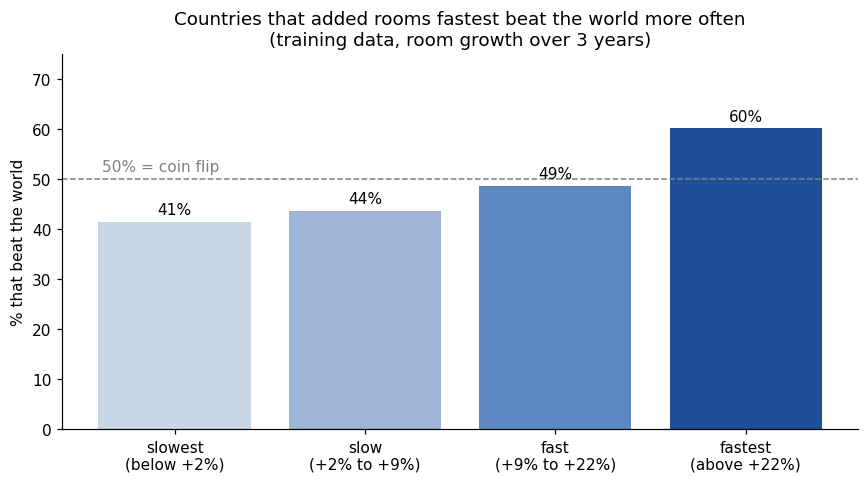

In [10]:
quartile = pd.qcut(train.rooms_growth_3y, 4)
share = train.groupby(quartile, observed=True)[TARGET].mean()
labels = [f"{iv.left:+.0%} to {iv.right:+.0%}" for iv in share.index]
labels[0] = f"below {share.index[0].right:+.0%}"
labels[-1] = f"above {share.index[-1].left:+.0%}"

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(["slowest", "slow", "fast", "fastest"], share * 100,
              color=["#c9d6e8", "#9db4d6", "#5f88c2", "#1f4e99"])
ax.bar_label(bars, labels=[f"{v:.0%}" for v in share], padding=3)
ax.axhline(50, color="grey", ls="--", lw=1)
ax.text(-0.38, 51.5, "50% = coin flip", color="grey", ha="left")
ax.set_xticks(range(4), [f"{n}\n({l})" for n, l in zip(["slowest", "slow", "fast", "fastest"], labels)])
ax.set_ylabel("% that beat the world")
ax.set_ylim(0, 75)
ax.set_title("Countries that added rooms fastest beat the world more often\n(training data, room growth over 3 years)")
plt.tight_layout()
plt.show()

There's a pattern, but it's not strong. Even in the fastest group about 4 in 10 didn't beat the world.

Below are the raw distributions. We cut the view at the 1st and 99th percentile so the charts are readable. Growth rates, currency change and inflation have very long tails (hyperinflation, currency resets), and the money columns cover several orders of magnitude.

,count,mean,std,min,1%,50%,99%,max
rooms_growth_3y,2056.0,0.150,0.238,-0.478,-0.276,0.094,1.088,1.996
arrivals_growth_1y,1873.0,0.070,0.190,-0.861,-0.331,0.051,0.717,3.142
spend_growth_past_1y,2036.0,0.126,0.826,-0.862,-0.494,0.069,1.264,29.625
fx_change_1y,1970.0,0.094,2.639,-1.000,-0.166,0.000,0.716,116.678
inflation_pct,1883.0,5.579,13.334,-16.860,-2.207,3.216,46.138,324.997
spend_per_room_usd,2056.0,76824.275,116885.352,572.902,3055.294,47857.592,675248.704,1556800.173
spend_share_gdp_pct,2045.0,6.916,11.822,0.018,0.120,2.869,68.000,85.407
gdp_per_capita_usd,2045.0,14541.328,20293.576,141.526,242.172,5555.582,103929.305,123678.707


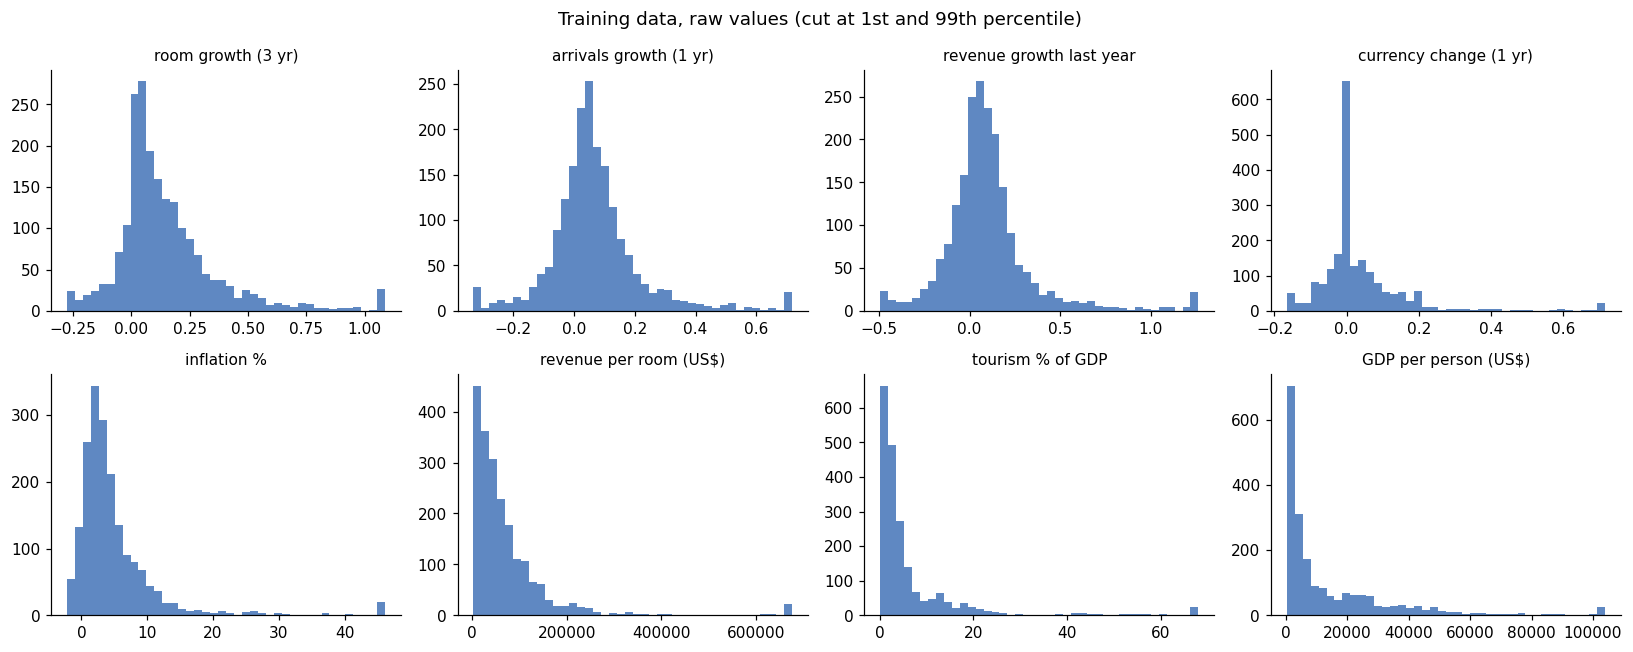

In [11]:
display(X_train[NUMERIC].describe(percentiles=[0.01, 0.5, 0.99]).T.round(3))
fig, axes = plt.subplots(2, 4, figsize=(15, 6))
for ax, column in zip(axes.ravel(), NUMERIC):
    values = X_train[column].dropna()
    ax.hist(values.clip(values.quantile(0.01), values.quantile(0.99)), bins=40, color="#5f88c2")
    ax.set_title(LABELS[column], fontsize=10)
fig.suptitle("Training data, raw values (cut at 1st and 99th percentile)")
plt.tight_layout()
plt.show()

The pipeline, the same for every model and refitted inside every CV fold:

1. Fixed transforms, nothing learned. Growth rates and inflation get `sign(x)·log(1+|x|)`, which keeps the sign but pulls in the extremes. Money columns get `log10`.
2. Fill missing values with the median of the training fold and add a column saying the value was missing.
3. Scale to mean 0, std 1. KNN needs this because it works with distances, so without scaling GDP per person (thousands) would outweigh a growth rate of 0.1. Logistic regression needs it because `C` penalises all weights the same, which is only fair if features are on the same scale. The random forest doesn't need it, but it doesn't hurt.
4. One-hot encode income group and region.

In [12]:
signed_log = lambda x: np.sign(x) * np.log1p(np.abs(x))
GROWTH = ["rooms_growth_3y", "arrivals_growth_1y", "spend_growth_past_1y", "fx_change_1y", "inflation_pct"]
MONEY = ["spend_per_room_usd", "spend_share_gdp_pct", "gdp_per_capita_usd"]

def numeric_branch(transform):
    return Pipeline([("transform", FunctionTransformer(transform, feature_names_out="one-to-one")),
                     ("impute", SimpleImputer(strategy="median", add_indicator=True)),
                     ("scale", StandardScaler())])

preprocess = ColumnTransformer([
    ("growth", numeric_branch(signed_log), GROWTH),
    ("money", numeric_branch(np.log10), MONEY),
    ("groups", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                         ("onehot", OneHotEncoder(handle_unknown="ignore"))]), CATEGORICAL),
])

def make_pipeline(model):
    return Pipeline([("prep", clone(preprocess)), ("model", model)])

# 5 folds grouped by country, the same folds for every model and both baselines
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
folds = list(cv.split(X_train, y_train, groups=g_train))
SCORING = {"f1": "f1", "precision": "precision", "recall": "recall"}
print("Validation rows per fold:", [len(v) for _, v in folds])

Validation rows per fold: [360, 482, 436, 371, 407]


## 5. Baselines

- `DummyClassifier(most_frequent)`, which the brief requires. With 50/50 classes it mostly says "no", so its F1 is close to 0.
- A one-line rule: say yes if room growth is above the training median. Anyone could do this in Excel. If the models can't beat it, they're not worth the extra work.

In [13]:
class RoomsRule(ClassifierMixin, BaseEstimator):
    """Predict 1 when rooms_growth_3y is above its median in the training data."""
    def fit(self, X, y):
        self.threshold_ = X["rooms_growth_3y"].median()
        self.classes_ = np.array([0, 1])
        return self
    def predict(self, X):
        return (X["rooms_growth_3y"] > self.threshold_).astype(int).to_numpy()

baselines = {"Dummy (most frequent)": make_pipeline(DummyClassifier(strategy="most_frequent")),
             "Rule: room growth > median": RoomsRule()}
baseline_cv = {}
for name, estimator in baselines.items():
    scores = cross_validate(estimator, X_train, y_train, cv=folds, scoring=SCORING)
    baseline_cv[name] = scores
    print(f"{name:28s} CV F1 = {scores['test_f1'].mean():.3f} ± {scores['test_f1'].std():.3f}")

Dummy (most frequent)        CV F1 = 0.118 ± 0.237
Rule: room growth > median   CV F1 = 0.552 ± 0.032


## 6. Tuning with cross-validation

`GridSearchCV` on the training countries only, with the same 5 folds and F1 for all three models.

In [14]:
def tune(model, grid):
    search = GridSearchCV(make_pipeline(model), grid, cv=folds, scoring=SCORING, refit="f1",
                          return_train_score=True, n_jobs=-1)
    search.fit(X_train, y_train)
    results = pd.DataFrame(search.cv_results_)
    print("Best:", search.best_params_, f"| CV F1 = {search.best_score_:.3f} ± "
          f"{results.loc[search.best_index_, 'std_test_f1']:.3f}")
    return search, results

def plot_scores(results, param, xlabel, title, split_by=None, log=False, xticks=None):
    fig, ax = plt.subplots(figsize=(8, 5))
    groups = results.groupby(f"param_{split_by}") if split_by else [(None, results)]
    for i, (value, part) in enumerate(groups):
        x = part[f"param_{param}"].astype(float)
        tag = f" ({split_by.replace('model__', '')}={value})" if split_by else ""
        line = ax.errorbar(x, part.mean_test_f1, yerr=part.std_test_f1, marker="o", capsize=3,
                           label="validation" + tag)
        ax.plot(x, part.mean_train_f1, ls="--", alpha=0.5, color=line[0].get_color(), label="train" + tag)
    best = results.loc[results.mean_test_f1.idxmax()]
    ax.scatter(float(best[f"param_{param}"]), best.mean_test_f1, s=200, facecolors="none",
               edgecolors="black", zorder=5, label="best")
    ax.axhline(baseline_cv["Rule: room growth > median"]["test_f1"].mean(), color="grey", ls=":",
               label="one-line rule")
    if log:
        ax.set_xscale("log")
    if xticks:
        ax.set_xticks(list(xticks.values()), list(xticks.keys()))
    ax.set_xlabel(xlabel); ax.set_ylabel("F1")
    ax.set_title(title + "\n(error bars = spread over 5 folds)")
    ax.legend(fontsize=8, ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.18))
    plt.tight_layout()
    plt.show()

COLS = ["mean_test_f1", "std_test_f1", "mean_test_precision", "mean_test_recall", "mean_train_f1"]

### Model 1: KNN

**What it does:** to judge a country-year it looks up the k most similar country-years in the training data and lets them vote.
**What we tune:** `n_neighbors` (small k follows noise, big k averages everything out) and `weights` (whether closer neighbours count more).
**Expected problem:** the nearest neighbours are often other years of very similar countries, and it can't tell you which feature mattered.

Best: {'model__n_neighbors': 11, 'model__weights': 'uniform'} | CV F1 = 0.516 ± 0.066


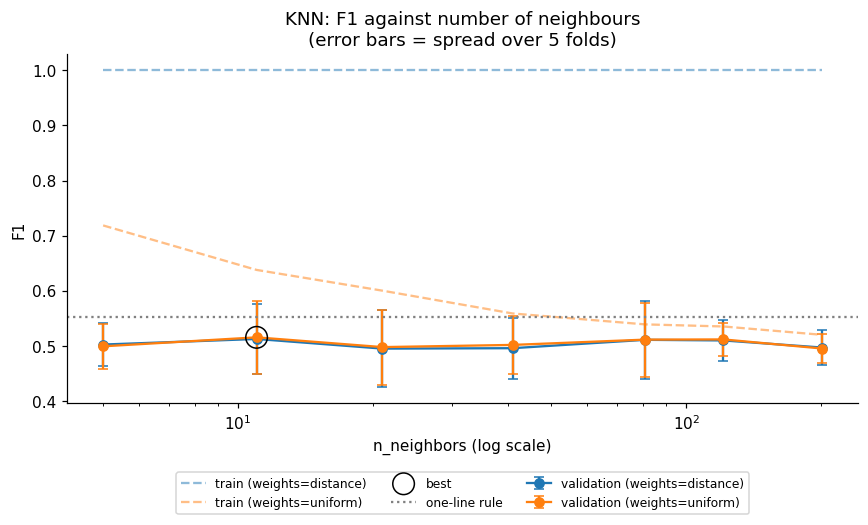

,param_model__n_neighbors,param_model__weights,mean_test_f1,std_test_f1,mean_test_precision,mean_test_recall,mean_train_f1
2,11,uniform,0.516,0.066,0.548,0.493,0.638
3,11,distance,0.513,0.064,0.545,0.490,1.000
8,81,uniform,0.512,0.067,0.568,0.477,0.539
10,121,uniform,0.512,0.030,0.581,0.468,0.536
9,81,distance,0.511,0.071,0.574,0.473,1.000
11,121,distance,0.510,0.037,0.584,0.465,1.000


In [15]:
knn_search, knn_results = tune(KNeighborsClassifier(),
                               {"model__n_neighbors": [5, 11, 21, 41, 81, 121, 201],
                                "model__weights": ["uniform", "distance"]})
plot_scores(knn_results, "model__n_neighbors", "n_neighbors (log scale)", "KNN: F1 against number of neighbours",
            split_by="model__weights", log=True)
display(knn_results[["param_model__n_neighbors", "param_model__weights"] + COLS].round(3)
        .sort_values("mean_test_f1", ascending=False).head(6))

With `distance` weights the train F1 is 1.0, because every point is its own nearest neighbour. Validation stays around 0.51 whatever k is, so KNN doesn't find much here.

### Model 2: Logistic regression

**What it does:** gives every feature a weight, adds them up and turns the total into a probability. A positive weight on room growth means more rooms, higher chance. This is the easiest model to explain to a ministry.
**What we tune:** `C`. Small C pushes weights towards 0 (simpler model), big C lets them grow.

Best: {'model__C': 0.1} | CV F1 = 0.561 ± 0.050


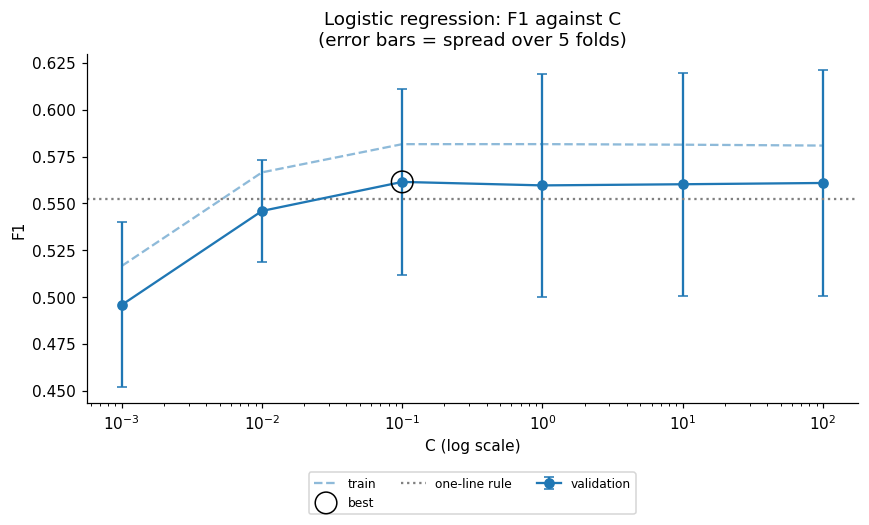

,param_model__C,mean_test_f1,std_test_f1,mean_test_precision,mean_test_recall,mean_train_f1
0,0.001,0.496,0.044,0.581,0.445,0.517
1,0.010,0.546,0.027,0.563,0.536,0.567
2,0.100,0.561,0.050,0.572,0.559,0.582
3,1.000,0.560,0.059,0.573,0.559,0.582
4,10.000,0.560,0.059,0.572,0.561,0.581
5,100.000,0.561,0.060,0.573,0.562,0.581


In [16]:
lr_search, lr_results = tune(LogisticRegression(max_iter=5000), {"model__C": [0.001, 0.01, 0.1, 1, 10, 100]})
plot_scores(lr_results, "model__C", "C (log scale)", "Logistic regression: F1 against C", log=True)
display(lr_results[["param_model__C"] + COLS].round(3))

From C = 0.1 upwards the score is flat and train is close to validation, so there's no overfitting. Only a very small C hurts, because the model gets too simple.

### Model 3: Random forest (our choice)

**What it does:** 300 decision trees, each trained on a random part of the data, and they vote. A tree asks things like "did rooms grow more than 20%?" or "is inflation high?".
**Why we picked it:** it can handle long tails and combinations, for example room growth only helping when inflation is low. It also shows which features it uses.
**What we tune:** `max_depth` (how many questions per tree) and `min_samples_leaf` (the minimum number of rows behind each answer). Both control overfitting.

Best: {'model__max_depth': None, 'model__min_samples_leaf': 5} | CV F1 = 0.589 ± 0.040


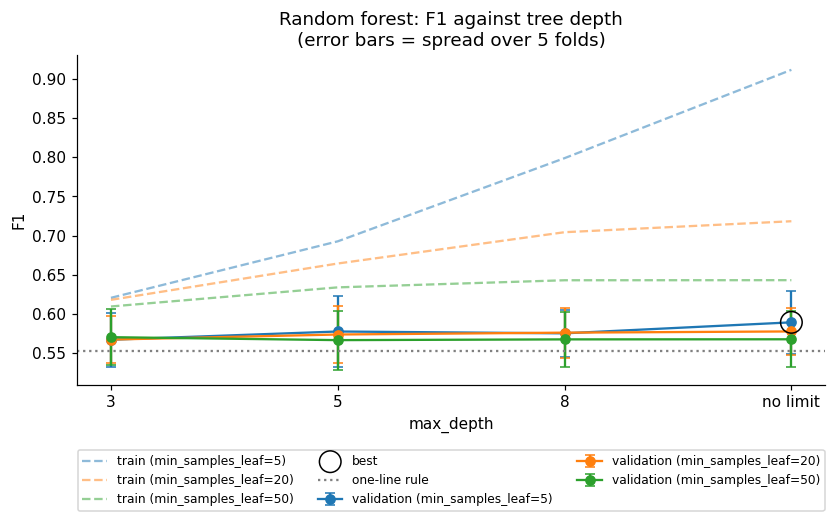

,param_model__max_depth,param_model__min_samples_leaf,mean_test_f1,std_test_f1,mean_test_precision,mean_test_recall,mean_train_f1
9,None,5,0.589,0.040,0.584,0.598,0.912
10,None,20,0.578,0.030,0.568,0.592,0.718
3,5,5,0.577,0.045,0.570,0.592,0.693
7,8,20,0.576,0.032,0.568,0.589,0.704
6,8,5,0.575,0.030,0.573,0.581,0.799
4,5,20,0.574,0.037,0.567,0.587,0.664


In [17]:
rf_search, rf_results = tune(RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1),
                             {"model__max_depth": [3, 5, 8, None],
                              "model__min_samples_leaf": [5, 20, 50]})
rf_plot = rf_results.copy()
depth_pos = {3: 1, 5: 2, 8: 3, None: 4}   # evenly spaced so the chart is readable
rf_plot["param_model__max_depth"] = [depth_pos[None if v is None or pd.isna(v) else int(v)]
                                     for v in rf_plot.param_model__max_depth]
plot_scores(rf_plot, "model__max_depth", "max_depth", "Random forest: F1 against tree depth",
            split_by="model__min_samples_leaf", xticks={"3": 1, "5": 2, "8": 3, "no limit": 4})

display(rf_results[["param_model__max_depth", "param_model__min_samples_leaf"] + COLS].round(3)
        .sort_values("mean_test_f1", ascending=False).head(6))

The best setting (no depth limit, 5 rows per leaf) has train F1 around 0.91 against 0.59 in validation, so it memorises a lot. Settings with shallower trees are only about 0.01 lower in validation and overfit much less. That difference is smaller than the spread over folds.

## 6b. Overfitting or underfitting?

The grids above were small, so here we zoom out. Three checks, all on training data with the same 5 folds. The test set is still untouched.

**1. Validation curves over a wide range.** Each model goes from very simple to very complex. How to read them:
- train high and validation much lower: **overfitting** (it memorises the training countries)
- both low and close together: **underfitting** (too simple to find the pattern)
- the best spot is where validation is highest

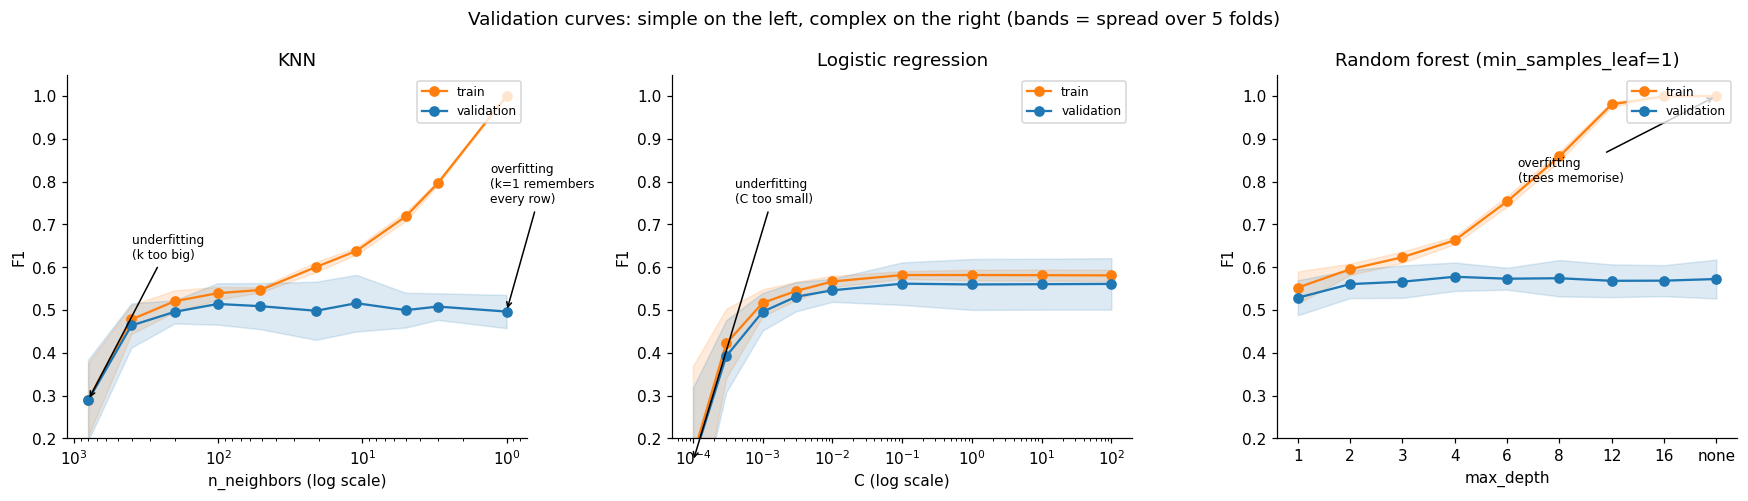

In [18]:
from sklearn.model_selection import validation_curve, learning_curve
from sklearn.inspection import DecisionBoundaryDisplay

def curve_panel(ax, x, train_scores, val_scores, title, xlabel, log=False, xticklabels=None):
    for scores, label, color in [(train_scores, "train", "tab:orange"), (val_scores, "validation", "tab:blue")]:
        mean, std = scores.mean(axis=1), scores.std(axis=1)
        ax.plot(x, mean, marker="o", color=color, label=label)
        ax.fill_between(x, mean - std, mean + std, color=color, alpha=0.15)
    if log:
        ax.set_xscale("log")
    if xticklabels:
        ax.set_xticks(x, xticklabels)
    ax.set_title(title); ax.set_xlabel(xlabel); ax.set_ylabel("F1"); ax.set_ylim(0.2, 1.05)
    ax.legend(loc="upper right", fontsize=8)

wide = {
    "KNN": (make_pipeline(KNeighborsClassifier()), "model__n_neighbors", [1, 3, 5, 11, 21, 51, 101, 201, 401, 801]),
    "Logistic regression": (make_pipeline(LogisticRegression(max_iter=5000)), "model__C",
                            [0.0001, 0.0003, 0.001, 0.003, 0.01, 0.1, 1, 10, 100]),
    "Random forest": (make_pipeline(RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1)),
                      "model__max_depth", [1, 2, 3, 4, 6, 8, 12, 16, None]),
}
curves = {}
for name, (pipe, param, values) in wide.items():
    curves[name] = validation_curve(pipe, X_train, y_train, param_name=param, param_range=values,
                                    cv=folds, scoring="f1", n_jobs=-1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
tr, va = curves["KNN"]
curve_panel(axes[0], wide["KNN"][2], tr, va, "KNN", "n_neighbors (log scale)", log=True)
axes[0].annotate("overfitting\n(k=1 remembers\nevery row)", xy=(1, va[0].mean()), xytext=(1.3, 0.75), fontsize=8,
                 arrowprops=dict(arrowstyle="->"), annotation_clip=False)
axes[0].annotate("underfitting\n(k too big)", xy=(801, va[-1].mean()), xytext=(400, 0.62), fontsize=8,
                 arrowprops=dict(arrowstyle="->"), annotation_clip=False)
axes[0].invert_xaxis()   # so complexity grows to the right, like the other two

tr, va = curves["Logistic regression"]
curve_panel(axes[1], wide["Logistic regression"][2], tr, va, "Logistic regression", "C (log scale)", log=True)
axes[1].annotate("underfitting\n(C too small)", xy=(0.0001, va[0].mean()), xytext=(0.0004, 0.75), fontsize=8,
                 arrowprops=dict(arrowstyle="->"), annotation_clip=False)

tr, va = curves["Random forest"]
pos = list(range(1, len(wide["Random forest"][2]) + 1))
curve_panel(axes[2], pos, tr, va, "Random forest (min_samples_leaf=1)", "max_depth",
            xticklabels=[str(v) if v else "none" for v in wide["Random forest"][2]])
axes[2].annotate("overfitting\n(trees memorise)", xy=(pos[-1], tr[-1].mean()), xytext=(5.2, 0.8), fontsize=8,
                 arrowprops=dict(arrowstyle="->"), annotation_clip=False)
fig.suptitle("Validation curves: simple on the left, complex on the right (bands = spread over 5 folds)")
plt.tight_layout()
plt.show()

- **KNN** shows both problems. At k=1 train is 1.0 but validation is only 0.50, a huge gap, which is classic overfitting. With very big k both lines fall together, which is underfitting. Validation never gets far above 0.5 anywhere, though.
- **Logistic regression** only underfits when C is tiny. After that train and validation stay close together. A straight-line model with 8 features can't memorise much, which is why it doesn't overfit.
- **Random forest** keeps going up on train as the trees get deeper, while validation stays flat around 0.57. The gap is overfitting, but it doesn't hurt validation much because the 200 trees average out each other's mistakes.

**2. Learning curves.** Same tuned models, trained on 10% up to 100% of the training folds. If the two lines are still far apart at the end, more data would help (overfitting). If they meet low, the features themselves are the limit (underfitting).

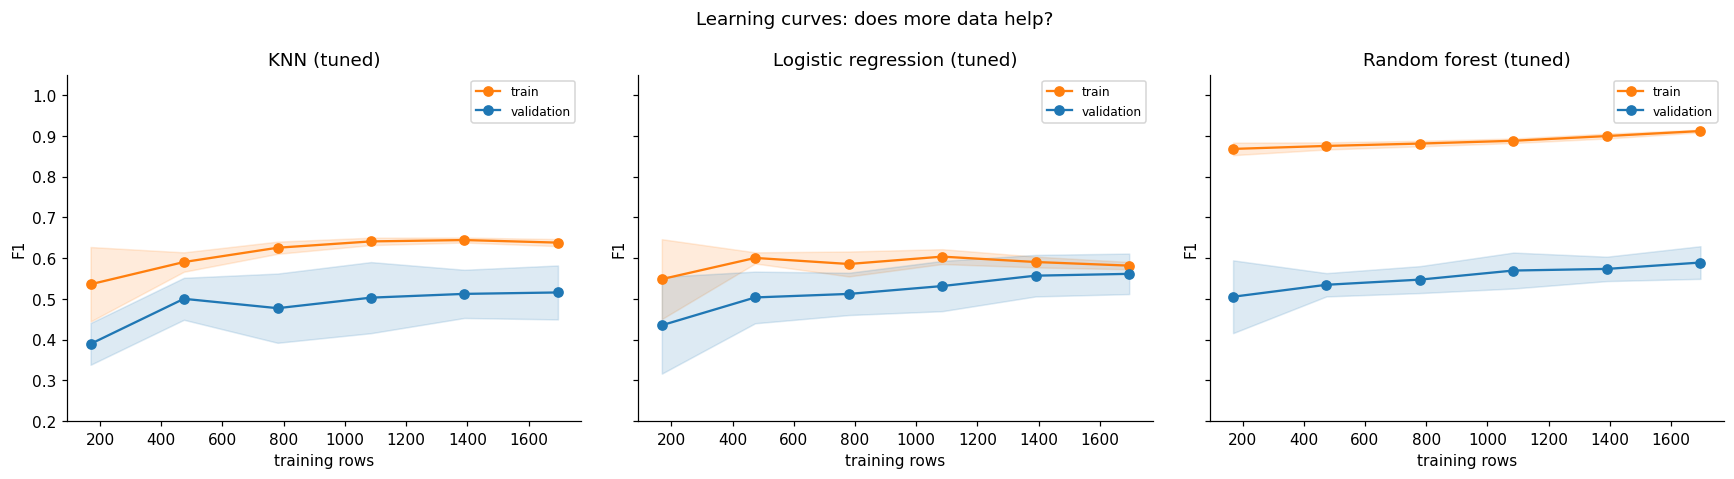

In [19]:
tuned = {"KNN": knn_search.best_estimator_, "Logistic regression": lr_search.best_estimator_,
         "Random forest": rf_search.best_estimator_}
fig, axes = plt.subplots(1, 3, figsize=(16, 4.4), sharey=True)
for ax, name in zip(axes, ["KNN", "Logistic regression", "Random forest"]):
    sizes, tr, va = learning_curve(tuned[name], X_train, y_train, cv=folds, scoring="f1",
                                   train_sizes=np.linspace(0.1, 1.0, 6), n_jobs=-1)
    curve_panel(ax, sizes, tr, va, f"{name} (tuned)", "training rows")
fig.suptitle("Learning curves: does more data help?")
plt.tight_layout()
plt.show()

- **Logistic regression:** the lines meet around 0.56 to 0.58 early on and stay there. More rows won't help. The limit is the information in the features, which is mild underfitting in the sense that the pattern is simply weak.
- **Random forest:** train stays far above validation, but validation creeps up slowly as rows are added. It overfits, and more data would help a little.
- **KNN (k=11):** a clear gap, and validation barely improves after about 500 rows. It overfits and more data doesn't fix it.

**3. The data points themselves.** To draw them we only use two features: room growth and arrivals growth. Each dot is one training country-year (blue = beat the world, red = didn't). The background colour shows what each model would predict. These are refitted on two features only, just for the picture, not the real models.

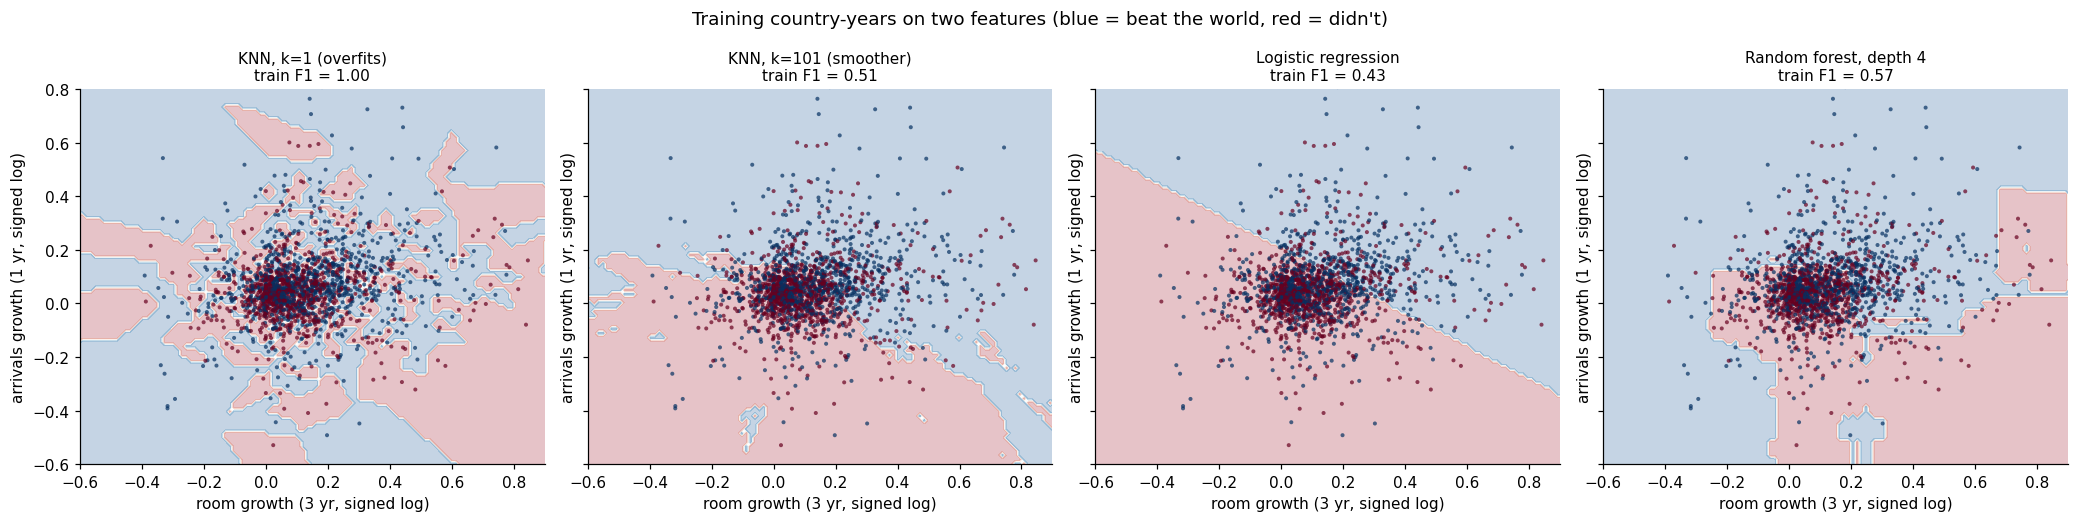

In [20]:
pair = ["rooms_growth_3y", "arrivals_growth_1y"]
pts = train.dropna(subset=pair)
X2 = signed_log(pts[pair]).rename(columns={"rooms_growth_3y": "room growth (3 yr, signed log)",
                                           "arrivals_growth_1y": "arrivals growth (1 yr, signed log)"})
y2 = pts[TARGET]
two_feature_models = {
    "KNN, k=1 (overfits)": KNeighborsClassifier(n_neighbors=1),
    "KNN, k=101 (smoother)": KNeighborsClassifier(n_neighbors=101),
    "Logistic regression": LogisticRegression(C=0.1),
    "Random forest, depth 4": RandomForestClassifier(n_estimators=200, max_depth=4, random_state=SEED),
}
fig, axes = plt.subplots(1, 4, figsize=(19, 4.8), sharey=True)
for ax, (name, clf) in zip(axes, two_feature_models.items()):
    model2 = Pipeline([("scale", StandardScaler()), ("model", clf)]).fit(X2, y2)
    DecisionBoundaryDisplay.from_estimator(model2, X2, response_method="predict", cmap="RdBu", alpha=0.25,
                                           ax=ax, grid_resolution=250)
    ax.scatter(X2.iloc[:, 0], X2.iloc[:, 1], c=y2, cmap="RdBu", s=7, edgecolors="none", alpha=0.7)
    ax.set_title(f"{name}\ntrain F1 = {f1_score(y2, model2.predict(X2)):.2f}", fontsize=10)
    ax.set_xlim(-0.6, 0.9); ax.set_ylim(-0.6, 0.8)
fig.suptitle("Training country-years on two features (blue = beat the world, red = didn't)")
plt.tight_layout()
plt.show()

This chart explains most of the results. Blue and red dots are mixed together almost everywhere, with only a bit more blue towards the top right (more rooms and more arrivals). KNN with k=1 draws a patchy map around every single dot, which is overfitting you can see. Logistic regression draws one straight line, and the forest a few blocks. No model can cleanly separate dots that overlap this much, so a test F1 of about 0.6 is close to what this data allows.

## 7. Test set (used once)

Each tuned model was refitted on all training countries. Now we score the test countries. Reading the table:
- train much higher than CV means overfitting
- CV close to test means the CV estimate was fair
- everything low means the signal in the data is weak

In [21]:
models = {"Dummy (most frequent)": baselines["Dummy (most frequent)"].fit(X_train, y_train),
          "Rule: room growth > median": baselines["Rule: room growth > median"].fit(X_train, y_train),
          "KNN": knn_search.best_estimator_,
          "Logistic regression": lr_search.best_estimator_,
          "Random forest": rf_search.best_estimator_}
searches = {"KNN": knn_search, "Logistic regression": lr_search, "Random forest": rf_search}

rows, predictions = [], {}
for name, model in models.items():
    pred_train, pred_test = model.predict(X_train), model.predict(X_test)
    predictions[name] = pred_test
    if name in searches:
        s = searches[name]; r = pd.DataFrame(s.cv_results_).loc[s.best_index_]
        params = {k.replace("model__", ""): v for k, v in s.best_params_.items()}
        cv_f1, cv_std = r.mean_test_f1, r.std_test_f1
    else:
        params, cv_f1, cv_std = "-", baseline_cv[name]["test_f1"].mean(), baseline_cv[name]["test_f1"].std()
    rows.append({"model": name, "best hyperparameters": params,
                 "train F1": f1_score(y_train, pred_train, zero_division=0),
                 "CV F1": cv_f1, "CV F1 std": cv_std,
                 "test precision": precision_score(y_test, pred_test, zero_division=0),
                 "test recall": recall_score(y_test, pred_test, zero_division=0),
                 "test F1": f1_score(y_test, pred_test, zero_division=0)})
comparison = pd.DataFrame(rows).set_index("model").round(3)
comparison

,best hyperparameters,train F1,CV F1,CV F1 std,test precision,test recall,test F1
model,,,,,,,
Dummy (most frequent),-,0.000,0.118,0.237,0.000,0.000,0.000
Rule: room growth > median,-,0.552,0.552,0.032,0.559,0.559,0.559
KNN,"{'n_neighbors': 11, 'weights': 'uniform'}",0.632,0.516,0.066,0.538,0.422,0.473
Logistic regression,{'C': 0.1},0.575,0.561,0.050,0.597,0.604,0.600
Random forest,"{'max_depth': None, 'min_samples_leaf': 5}",0.914,0.589,0.040,0.609,0.578,0.593


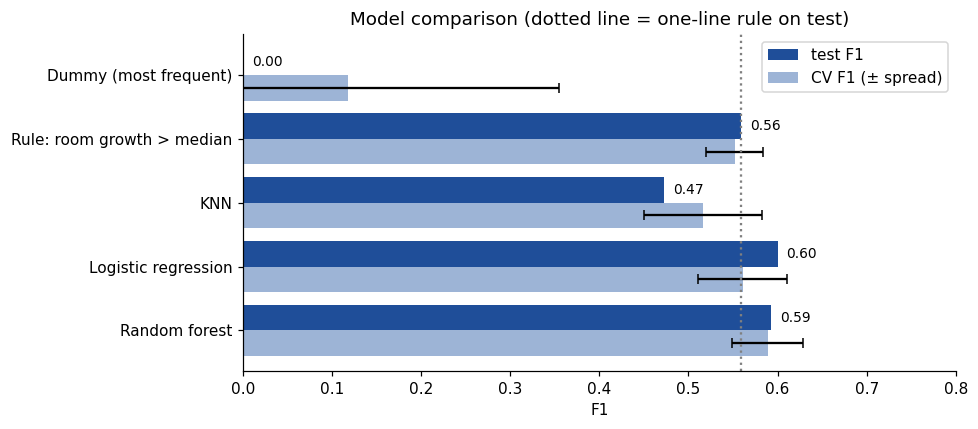

In [22]:
fig, ax = plt.subplots(figsize=(9, 4))
order = comparison.index[::-1]
y = np.arange(len(order))
ax.barh(y + 0.2, comparison.loc[order, "test F1"], height=0.4, color="#1f4e99", label="test F1")
ax.barh(y - 0.2, comparison.loc[order, "CV F1"], height=0.4, xerr=comparison.loc[order, "CV F1 std"],
        color="#9db4d6", capsize=3, label="CV F1 (± spread)")
for yi, v in zip(y, comparison.loc[order, "test F1"]):
    ax.text(v + 0.01, yi + 0.2, f"{v:.2f}", va="center", fontsize=9)
ax.axvline(comparison.loc["Rule: room growth > median", "test F1"], color="grey", ls=":")
ax.set_yticks(y, order)
ax.set_xlim(0, 0.8)
ax.set_xlabel("F1")
ax.set_title("Model comparison (dotted line = one-line rule on test)")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

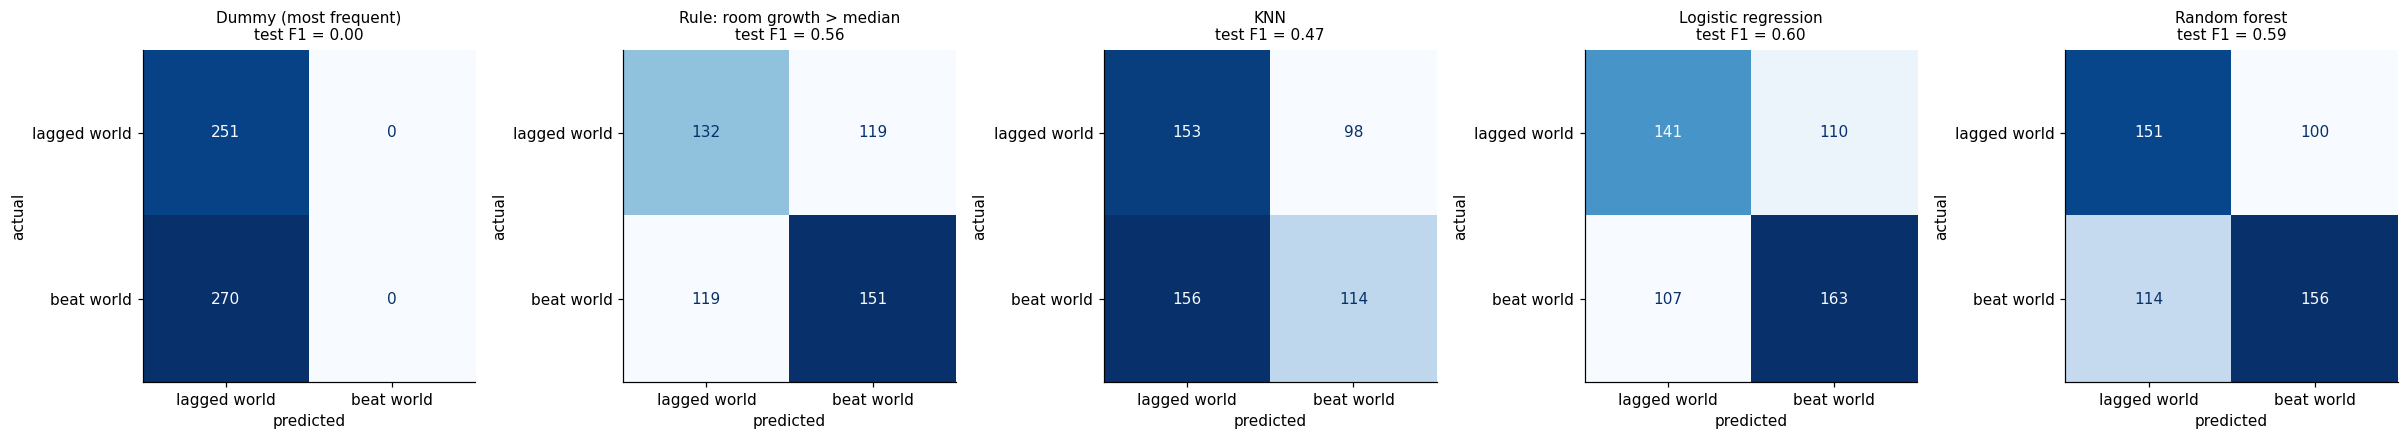

In [23]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, name in zip(axes, models):
    ConfusionMatrixDisplay(confusion_matrix(y_test, predictions[name], labels=[0, 1]),
                           display_labels=["lagged world", "beat world"]).plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"{name}\ntest F1 = {comparison.loc[name, 'test F1']:.2f}", fontsize=10)
    ax.set_xlabel("predicted"); ax.set_ylabel("actual")
plt.tight_layout()
plt.show()

### What the models look at

Left: logistic regression weights for the numeric features. Green means it raises the chance of beating the world, red means it lowers it. Right: how much the random forest uses each feature, with the one-hot and missing-value columns added back to their original feature.

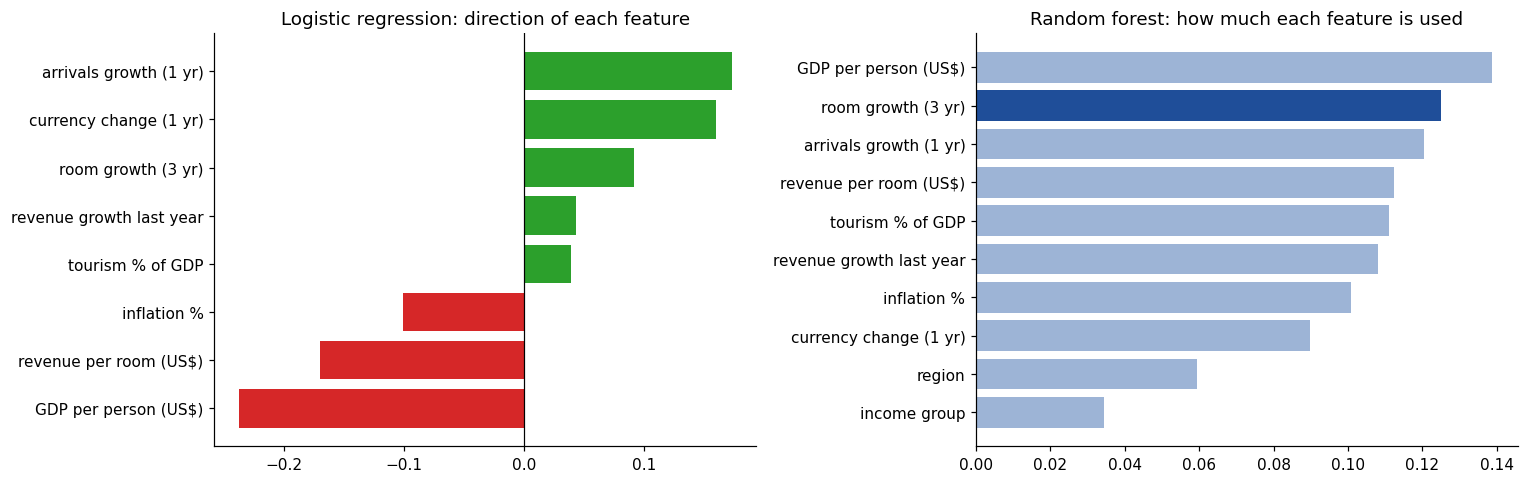

In [24]:
prep = lr_search.best_estimator_.named_steps["prep"]
names_out = prep.get_feature_names_out()
def original(name):
    name = name.split("__", 1)[1].replace("missingindicator_", "")
    return next(f for f in FEATURES if name.startswith(f))

coefs = pd.Series(lr_search.best_estimator_.named_steps["model"].coef_[0], index=names_out)
coefs = coefs[[n.split("__", 1)[1] in NUMERIC for n in coefs.index]]
coefs.index = [LABELS[n.split("__", 1)[1]] for n in coefs.index]
coefs = coefs.sort_values()
importance = pd.Series(rf_search.best_estimator_.named_steps["model"].feature_importances_,
                       index=[LABELS[original(n)] for n in names_out]).groupby(level=0).sum().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].barh(coefs.index, coefs, color=np.where(coefs > 0, "tab:green", "tab:red"))
axes[0].axvline(0, color="black", lw=0.8)
axes[0].set_title("Logistic regression: direction of each feature")
bars = axes[1].barh(importance.index, importance,
                    color=["#1f4e99" if i == "room growth (3 yr)" else "#9db4d6" for i in importance.index])
axes[1].set_title("Random forest: how much each feature is used")
plt.tight_layout()
plt.show()

Room growth pushes the prediction up, and the random forest uses it more than almost any other feature. But it isn't the only thing that matters. In the logistic regression, arrivals growth and a weaker currency push up more than rooms do. Richer countries, and countries where each room already earns a lot, are less likely to beat the world. That makes sense: poorer countries are catching up and grow faster.

## 8. Errors and the group check

The groups here are World Bank income groups. Some are small, so we show the row count with each score.

,rows,share beats world,precision,recall,F1,false positive rate
income_group,,,,,,
Low income,48.0,0.604,0.625,0.690,0.656,0.632
Lower middle income,71.0,0.451,0.453,0.750,0.565,0.744
Upper middle income,197.0,0.553,0.635,0.798,0.707,0.568
High income,205.0,0.488,0.627,0.320,0.424,0.181


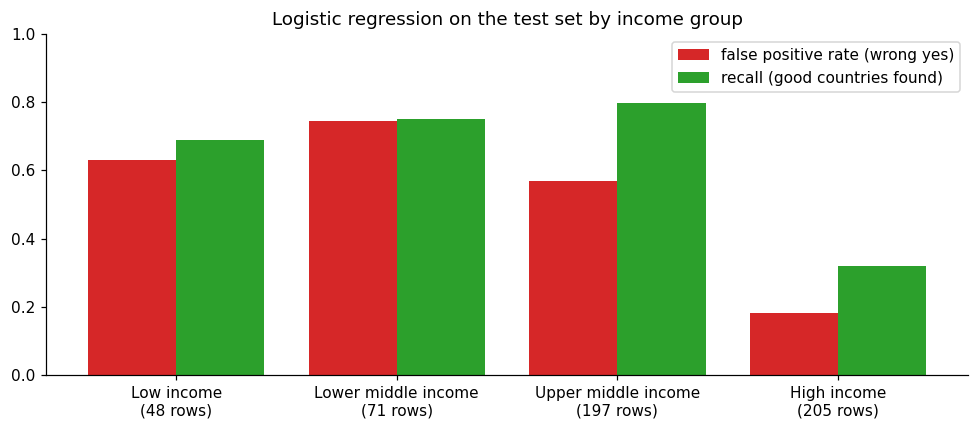

,rows,share beats world,precision,recall,F1,false positive rate
region,,,,,,
East Asia & Pacific,80.0,0.588,0.588,1.000,0.740,1.000
Europe & Central Asia,154.0,0.545,0.677,0.500,0.575,0.286
Latin America & Caribbean,116.0,0.466,0.571,0.444,0.500,0.290
"Middle East, North Africa, Afghanistan & Pakistan",108.0,0.481,0.521,0.731,0.608,0.625
Sub-Saharan Africa,63.0,0.524,0.750,0.364,0.490,0.133


In [25]:
BEST = "Logistic regression"   # chosen in step 9
errors = test.assign(pred=predictions[BEST], prob=models[BEST].predict_proba(X_test)[:, 1])

def group_scores(column):
    return (errors.groupby(column)
                  .apply(lambda g: pd.Series({"rows": len(g), "share beats world": g[TARGET].mean(),
                                              "precision": precision_score(g[TARGET], g.pred, zero_division=0),
                                              "recall": recall_score(g[TARGET], g.pred, zero_division=0),
                                              "F1": f1_score(g[TARGET], g.pred, zero_division=0),
                                              "false positive rate": ((g.pred == 1) & (g[TARGET] == 0)).sum()
                                                                     / max((g[TARGET] == 0).sum(), 1)}),
                         include_groups=False)
                  .round(3))

by_income = group_scores("income_group").reindex(
    ["Low income", "Lower middle income", "Upper middle income", "High income"])
display(by_income)

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(by_income))
ax.bar(x - 0.2, by_income["false positive rate"], width=0.4, color="tab:red", label="false positive rate (wrong yes)")
ax.bar(x + 0.2, by_income["recall"], width=0.4, color="tab:green", label="recall (good countries found)")
ax.set_xticks(x, [f"{i}\n({int(n)} rows)" for i, n in zip(by_income.index, by_income.rows)])
ax.set_ylim(0, 1)
ax.set_title(f"{BEST} on the test set by income group")
ax.legend()
plt.tight_layout()
plt.show()
display(group_scores("region"))

This is the most important result for the ethics part. For high-income countries the model rarely gives a wrong yes, but for lower-middle and low-income countries most of the countries that lagged still got a yes. The model is too optimistic about poorer countries, and that's exactly where a bad investment hurts the most. The groups are small (48 and 71 rows), so the exact numbers are uncertain, but the gap is big.

Below are the most confident mistakes.

In [26]:
show = ["country", "year", "income_group", "rooms_growth_3y", "spend_growth_next_2y", "world_median_next_2y", "prob"]
print("Wrong yes (said it would beat the world, it didn't):")
display(errors.query("pred == 1 and target_beats_world == 0").sort_values("prob", ascending=False)[show].head(8).round(3))
print("Wrong no (said it would lag, it actually beat the world):")
display(errors.query("pred == 0 and target_beats_world == 1").sort_values("prob")[show].head(8).round(3))

Wrong yes (said it would beat the world, it didn't):


,country,year,income_group,rooms_growth_3y,spend_growth_next_2y,world_median_next_2y,prob
208,Iraq,1998,Upper middle income,0.041,-0.867,0.059,0.785
513,Yemen,2003,Low income,0.272,0.302,0.304,0.770
119,China,2002,Upper middle income,0.009,0.263,0.372,0.718
122,China,2005,Upper middle income,0.485,0.271,0.298,0.711
446,Timor-Leste,2009,Lower middle income,0.351,0.125,0.173,0.710
510,Yemen,2000,Low income,0.356,-0.479,0.088,0.708
416,Syrian Arab Republic,2000,Low income,0.043,-0.104,0.088,0.701
428,Thailand,2000,Upper middle income,0.168,0.056,0.088,0.699


Wrong no (said it would lag, it actually beat the world):


,country,year,income_group,rooms_growth_3y,spend_growth_next_2y,world_median_next_2y,prob
298,Kuwait,2014,High income,0.003,0.626,0.004,0.302
50,Bahamas,2008,High income,0.101,0.001,-0.013,0.310
169,Denmark,2013,High income,0.069,0.030,0.028,0.313
59,Bahamas,2017,High income,0.055,0.408,0.127,0.313
344,Netherlands (Kingdom of the),2007,High income,0.064,0.066,0.023,0.315
154,Denmark,1998,High income,0.007,0.134,0.059,0.321
55,Bahamas,2013,High income,-0.026,0.110,0.028,0.323
155,Denmark,1999,High income,0.006,0.082,0.041,0.326


Several of the wrong yeses are Iraq, Yemen and Syria around 1998 to 2003, so wars and sanctions the data knows nothing about. The wrong noes are mostly rich countries with slow room growth (Denmark, the Bahamas, Kuwait) that still did well. Revenue can grow without new hotels, for example through higher prices or rentals that aren't counted.

## 9. Recommendation

Our pick is the **logistic regression**, but only as a first screen and not as the final decision.

- Test F1 is 0.60, against 0.56 for the one-line rule. That gap is about the same size as the spread over the folds (±0.05), so machine learning helps only a little.
- The random forest scores almost the same (0.59 test) but has train F1 0.91, so it memorises training countries. The logistic regression gets the same result without overfitting, and we can show the ministry which way each feature pushes.
- KNN is the weakest (0.47) and even loses to the one-line rule.
- The big warning is the group check. The model gives far too many wrong yeses for low and lower-middle income countries. For those countries a yes should mean "look closer", not "go ahead".

So room growth does go together with beating the world, but on its own it's a weak signal. It doesn't replace a proper study of each country.

## 10. Try it on a made-up country

A made-up lower-middle-income country in the Middle East and North Africa: rooms up 25% in 3 years, arrivals up 8%, revenue up 6% last year, currency 3% weaker, inflation 5%.

Logistic regression: beats the world, probability 52%


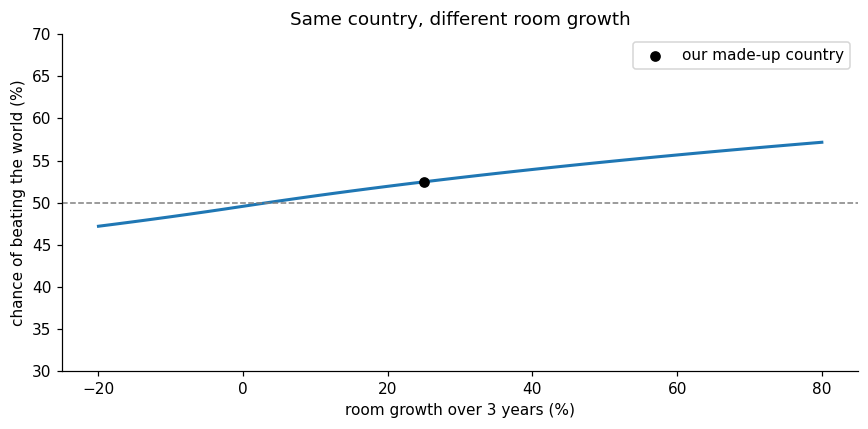

In [27]:
new_case = pd.DataFrame([{
    "rooms_growth_3y": 0.25, "arrivals_growth_1y": 0.08, "spend_growth_past_1y": 0.06,
    "fx_change_1y": 0.03, "inflation_pct": 5.0, "spend_per_room_usd": 40000,
    "spend_share_gdp_pct": 4.0, "gdp_per_capita_usd": 3500,
    "income_group": "Lower middle income", "region": "Middle East, North Africa, Afghanistan & Pakistan"}])
assert new_case.region.iloc[0] in set(df.region), "region name must exist in the data"
model = models[BEST]
probability = model.predict_proba(new_case[FEATURES])[0, 1]
verdict = "beats the world" if model.predict(new_case[FEATURES])[0] else "lags the world"
print(f"{BEST}: {verdict}, probability {probability:.0%}")

growth = np.linspace(-0.2, 0.8, 41)
probs = [model.predict_proba(new_case.assign(rooms_growth_3y=g)[FEATURES])[0, 1] for g in growth]
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(growth * 100, np.array(probs) * 100, lw=2)
ax.scatter([25], [probability * 100], color="black", zorder=5, label="our made-up country")
ax.axhline(50, color="grey", ls="--", lw=1)
ax.set_xlabel("room growth over 3 years (%)")
ax.set_ylabel("chance of beating the world (%)")
ax.set_ylim(30, 70)
ax.set_title("Same country, different room growth")
ax.legend()
plt.tight_layout()
plt.show()

More rooms move the chance up only a few points. That matches step 7: room growth helps, but the country's region and economy matter at least as much. For this lower-middle-income country the group check says to be careful with a yes.

## Limitations

- It shows things that go together, not cause and effect. Hotels get built where demand is already rising.
- Hotel rooms aren't the same as investment. Airports, marketing, Airbnb-type rentals and upgrades are missing. Platform data from Eurostat only starts in 2018, after our window.
- It only covers before COVID (1998 to 2017). There isn't enough data after COVID to test it yet.
- Rich countries have the most rows, and low-income countries are under-represented.
- Revenue is in nominal US$ and only counts foreign visitors, not domestic tourists or taxes.
- Income group is today's classification, applied to older years.
- Train and test countries share the same calendar years. Comparing with the world median removes most of the shared shocks, but not all of them.